<a href="https://colab.research.google.com/github/SugiShanmu/Machine-Learning-/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sample Data:
   Area_sqft  Bedrooms   Location  Age_years  Price_Lakhs
0        800         1    Chennai          5           35
1       1200         2  Bangalore          2           55
2       1500         3    Chennai         10           60
3       1800         3      Delhi          3           85
4       2000         4  Bangalore          1           95
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Area_sqft    12 non-null     int64 
 1   Bedrooms     12 non-null     int64 
 2   Location     12 non-null     object
 3   Age_years    12 non-null     int64 
 4   Price_Lakhs  12 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 612.0+ bytes
None

R2 Score: 0.703
RMSE: 7.66

Feature scaling done? Mean ~0, Std ~1 for numeric
Encoding done? Location -> Bangalore, Chennai, Delhi converted to 0/1


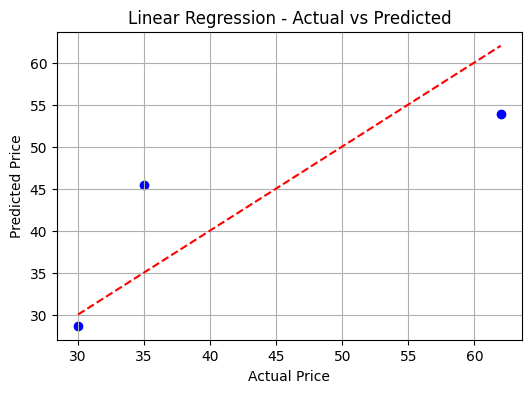


Scaled + Encoded shape: (12, 5)
First row scaled: [-2.10388113 -2.82842712  0.03031695  1.          0.        ]

Files generated: linear_regression_plot.png


<Figure size 640x480 with 0 Axes>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. SAMPLE DATA - House Price Prediction
data = {
    'Area_sqft': [800, 1200, 1500, 1800, 2000, 2200, 1000, 1600, 2500, 900, 1300, 2100],
    'Bedrooms': [1,2,3,3,4,4,2,3,4,1,2,4],
    'Location': ['Chennai','Bangalore','Chennai','Delhi','Bangalore','Delhi','Chennai','Bangalore','Delhi','Chennai','Delhi','Bangalore'],
    'Age_years': [5,2,10,3,1,7,12,4,2,15,6,3],
    'Price_Lakhs': [35,55,60,85,95,90,40,70,120,30,62,98]
}
df = pd.DataFrame(data)
print("Sample Data:")
print(df.head())
print(df.info())

# 2. SPLIT X, y
X = df.drop('Price_Lakhs', axis=1)
y = df['Price_Lakhs']

# 3. PREPROCESSING - Encoding + Feature Scaling (Normalisation)
# Numerical: Area, Bedrooms, Age -> StandardScaler (Normalization / Feature Scaling)
# Categorical: Location -> OneHotEncoder (Encoding)

numeric_features = ['Area_sqft', 'Bedrooms', 'Age_years']
categorical_features = ['Location']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), # Feature Scaling + Normalization
        ('cat', OneHotEncoder(drop='first'), categorical_features) # Encoding
    ])

# 4. PIPELINE - Preprocessing + Linear Regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 5. TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 6. TRAIN
model.fit(X_train, y_train)

# 7. PREDICT
y_pred = model.predict(X_test)

# 8. EVALUATE
print(f"\nR2 Score: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Show coefficients
print("\nFeature scaling done? Mean ~0, Std ~1 for numeric")
print("Encoding done? Location -> Bangalore, Chennai, Delhi converted to 0/1")

# 9. VISUALIZATION
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression - Actual vs Predicted")
plt.grid(True)
plt.show()

# 10. SAVE PROCESSED DATA FOR GITHUB
# Get scaled data
X_scaled = model.named_steps['preprocessor'].transform(X)
print(f"\nScaled + Encoded shape: {X_scaled.shape}")
print("First row scaled:", X_scaled[0])

# Save plot
plt.savefig("linear_regression_plot.png")
print("\nFiles generated: linear_regression_plot.png")